# Entendimiento inicial de los datos

El conjunto de datos transformado integra información proveniente de Grizzly junto con datos internos de la empresa, consolidando tareas, proyectos y equipos. Incluye identificadores (tarea_id, proyecto_id), fechas de creación, duraciones planeadas y reales, fuente de registro, estado y tipo de oferta. También incorpora datos temporales del equipo (creación, eliminación y meses activos) y fechas clave del registro y ejecución de las tareas por parte de los empleados. Esta integración ofrece una visión completa del ciclo de vida de los proyectos y sirve como insumo para el modelo predictivo.

In [1]:
!pip install scikit-learn
!pip install xgboost
!pip install lime
!pip install shap



[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Importación de librerías
import pandas as pd
import numpy as np
from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score, precision_score, recall_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor
import xgboost as xgb
import shap
import lime
from lime.lime_tabular import LimeTabularExplainer
pd.set_option('display.max_columns', None)

In [3]:
tracking_df=pd.read_csv("maestra_segunda_entrega.csv")

C:\Users\Diego\AppData\Local\Temp\ipykernel_5008\3484376355.py:1: DtypeWarning: Columns (4,19,21,25) have mixed types. Specify dtype option on import or set low_memory=False.
  tracking_df=pd.read_csv("maestra_segunda_entrega.csv")


In [4]:
tracking_df=tracking_df[(tracking_df["duracion_real_total_tarea"] >= 0) & (tracking_df["id_registro_declaracion"].notnull())]

In [5]:
tracking_df_clean = (
    tracking_df
    .groupby(["proyecto_id", "team_id", "estado", "oferta"])
    .agg({
        "tarea_id": pd.Series.nunique,                       # count_distinct
        "id_registro_declaracion": pd.Series.nunique,        # count_distinct
        "fuente": lambda x: x.value_counts().idxmax(),      # moda
        "duracion_total_planeada_projecto": "max",
        "duracion_real_total_projecto": "max",
        "duracion_meses_team": "max",
    })
    .rename(columns={
        "tarea_id": "cantidad_tareas",
        "id_registro_declaracion": "num_seguimientos",
        "duracion_total_planeada_projecto":"duracion_planeada_total_projecto",
    })
    .reset_index()
)

In [6]:
print(tracking_df.shape)
print(tracking_df_clean.shape)

(4436742, 28)
(49506, 10)


- Se filtran las columnas que dan valor al modelo


In [7]:
cols_eliminar=["team_id","proyecto_id"]
tracking_df_clean=tracking_df_clean.drop(columns=cols_eliminar)

- Se observa la distribucion de la columna objetivo "duracion_real_total_projecto"

In [8]:
tracking_df_clean["duracion_real_total_projecto"].skew()

np.float64(58.82873297457198)

Se observa una asimetria postiva en la variable. Por lo tanto se va a observar por intervalos de horas la cantidad de tareas que existen.

<Axes: xlabel='duracion_real_total_projecto'>

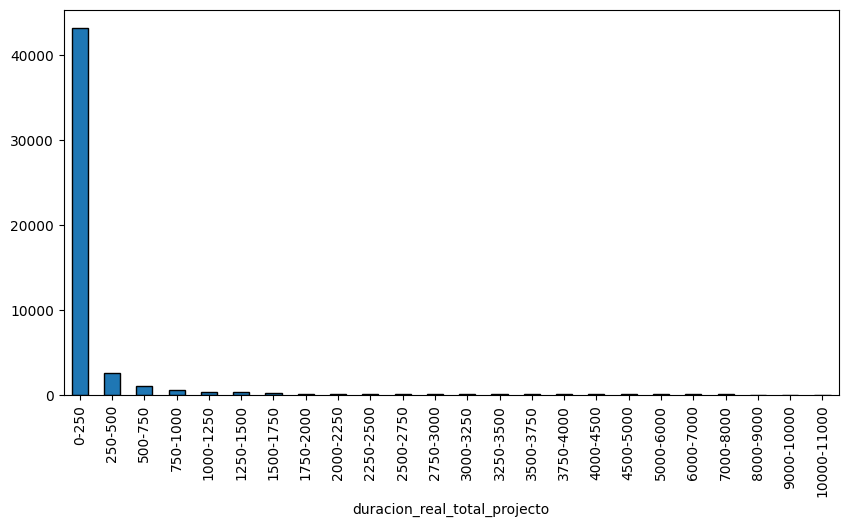

In [9]:
tareas=tracking_df_clean["duracion_real_total_projecto"]
bins=[0,250,500,750,1000,1250,1500,1750,2000,2250,2500,2750,3000,3250,3500,3750,4000,4500,5000,6000,7000,8000,9000,10000,11000]
labels=[
    "0-250",
    "250-500",
    "500-750",
    "750-1000",
    "1000-1250",
    "1250-1500",
    "1500-1750",
    "1750-2000",
    "2000-2250",
    "2250-2500",
    "2500-2750",
    "2750-3000",
    "3000-3250",
    "3250-3500",
    "3500-3750",
    "3750-4000",
    "4000-4500",
    "4500-5000",
    "5000-6000",
    "6000-7000",
    "7000-8000",
    "8000-9000",
    "9000-10000",
    "10000-11000"
]
rangos=pd.cut(tareas,bins=bins,labels=labels,include_lowest=True)
frecuencias=rangos.value_counts().sort_index()
plt.figure(figsize=(10,5))
frecuencias.plot(kind="bar",edgecolor="black")

Con base a los intervalos observados, se va a limitar la variable tarjet entre un rango de mas de 1h hasta menos de 250 horas

In [10]:
tracking_df_clean=tracking_df_clean[(tracking_df_clean["duracion_real_total_projecto"]>0) & (tracking_df_clean["duracion_real_total_projecto"]<=250)]

- Se grafica nuevamente la variable en los intervalos

<Axes: xlabel='duracion_real_total_projecto'>

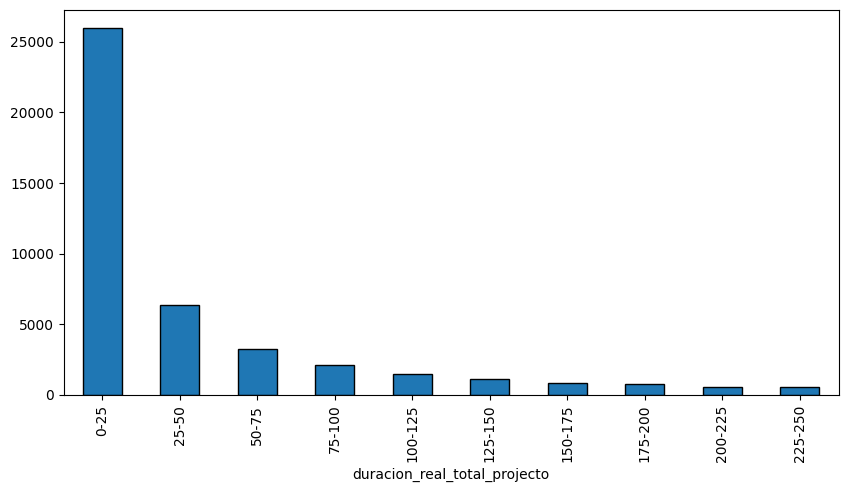

In [11]:
tareas=tracking_df_clean["duracion_real_total_projecto"]
bins=[0,25,50,75,100,125,150,175,200,225,250]
labels=[
    "0-25",
    "25-50",
    "50-75",
    "75-100",
    "100-125",
    "125-150",
    "150-175",
    "175-200",
    "200-225",
    "225-250"
]
rangos=pd.cut(tareas,bins=bins,labels=labels,include_lowest=True)
frecuencias=rangos.value_counts().sort_index()
plt.figure(figsize=(10,5))
frecuencias.plot(kind="bar",edgecolor="black")

- Haciendo un analisis mas a exhastivo entre el rango de 0 a 250 h, se observa que la mayoria de proyecto estan entre 0 y 25 horas por lo que el filtro final para la variable de duracion real proyecto sera el intervalo mencionado.

In [12]:
tracking_df_clean=tracking_df_clean[(tracking_df_clean["duracion_real_total_projecto"]>0) & (tracking_df_clean["duracion_real_total_projecto"]<=25)]

In [13]:
tracking_df_clean.shape

(25946, 8)

- Analisis variable "cantidad_tareas": se limita a 25 que es el numero maximo de distintas tareas que se pueden tener para proyectos de 25 horas

In [14]:
tracking_df_clean["cantidad_tareas"]=tracking_df_clean["cantidad_tareas"].clip(upper=25)

- Analisis variable "num_seguimientos": se limita la variable a 25 debido a que es el numero maximo de  seguimientos que se puede tener de una hora para proyectos que demoraron 25 horas

In [15]:
tracking_df_clean["num_seguimientos"]=tracking_df_clean["num_seguimientos"].clip(upper=25)

- Analisis variable "duracion_planeada_total_projecto"

In [16]:

tracking_df_clean["duracion_planeada_total_projecto"].describe()

count     25946.000000
mean         32.916775
std         748.323897
min           0.000000
25%           0.000000
50%           0.000000
75%           8.000000
max      100000.000000
Name: duracion_planeada_total_projecto, dtype: float64

Se observa que el valor maximo es 100_000, por lo tanto se considera un valor outlier porque una estimacion no deberia ser 4000 veces mayor a la real. Por lo tanto, se limita a que la estimacion puede ser hasta 3 veces mayor que la estimacion real, es decir, hasta 75 horas.


In [17]:
tracking_df_clean["duracion_planeada_total_projecto"]=tracking_df_clean["duracion_planeada_total_projecto"].clip(upper=75)

- Analisis variable "duracion_meses_team": se tiene cerca del 71% de valores en NAN, por lo que se imputa con la media.

In [18]:
tracking_df_clean["duracion_meses_team"].describe()

count    7668.000000
mean       23.335942
std        15.740629
min         2.000000
25%         8.000000
50%        19.000000
75%        33.000000
max        76.000000
Name: duracion_meses_team, dtype: float64

In [19]:
tracking_df_clean["duracion_meses_team"]=tracking_df_clean["duracion_meses_team"].fillna(tracking_df_clean["duracion_meses_team"].mean())

Transformaciones clave que mejoraron el desempeño

- Creación de variables agregadas como cantidad_tareas y num_seguimientos, orientadas a capturar la intensidad operativa de cada proyecto mediante conteos consolidados. 
- Tratamiento de la asimetría en variables numéricas, donde se identificó una asimetría positiva elevada. Se aplicó winsorización basada en criterios del negocio, reduciendo la influencia de outliers sin eliminar información relevante. Esta corrección contribuyó a disminuir el RMSE. 
- Depuración de valores atípicos en la variable objetivo (duracion_real_total_projecto), seleccionando rangos representativos de los proyectos con mayor frecuencia para mejorar la estabilidad del modelo. 
- Imputación de valores faltantes en la variable duracion_meses_team, reemplazando nulos por el promedio para preservar coherencia en el comportamiento histórico. 
- Codificación de variables categóricas mediante OneHotEncoder, adecuado dado que estas columnas no presentaban alta cardinalidad. 
- Estandarización de variables numéricas utilizando StandardScaler, para homogenizar escalas y favorecer el desempeño de modelos sensibles a magnitud. 

- Modelado

In [20]:
X = tracking_df_clean.drop(columns=["duracion_real_total_projecto"])
y = tracking_df_clean["duracion_real_total_projecto"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
cat_cols = X_train.select_dtypes(include="object").columns.tolist()
num_cols = X_train.select_dtypes(include="number").columns.tolist()
print(cat_cols)
print(num_cols)
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
scaler = StandardScaler()

X_train_cat = pd.DataFrame(
    ohe.fit_transform(X_train[cat_cols]),
    columns=ohe.get_feature_names_out(cat_cols),
    index=X_train.index
)
X_train_num = pd.DataFrame(
    scaler.fit_transform(X_train[num_cols]),
    columns=num_cols,
    index=X_train.index
)

X_test_cat = pd.DataFrame(
    ohe.transform(X_test[cat_cols]),
    columns=ohe.get_feature_names_out(cat_cols),
    index=X_test.index
)

X_test_num = pd.DataFrame(
    scaler.transform(X_test[num_cols]),
    columns=num_cols,
    index=X_test.index
)
X_train_final = pd.concat([X_train_num, X_train_cat], axis=1)
X_test_final = pd.concat([X_test_num, X_test_cat], axis=1)

['estado', 'oferta', 'fuente']
['cantidad_tareas', 'num_seguimientos', 'duracion_planeada_total_projecto', 'duracion_meses_team']


- Modelo Regresion Lineal

In [21]:
model = LinearRegression()
model.fit(X_train_final, y_train)
y_pred = model.predict(X_test_final)

print("MAE :", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R²  :", r2_score(y_test, y_pred))

MAE : 3.8554626264185132
RMSE: 4.9804330021998044
R²  : 0.4771838301831879


- Modelo Random Forest

- n_estimators (200–300): indica la cantidad de árboles de decisión que conforman el bosque.
- max_depth (None, 10, 20): controla la profundidad máxima de cada árbol.
- min_samples_split (2–5): determina el número mínimo de muestras requerido para dividir un nodo interno.
- min_samples_leaf (1–2): establece la cantidad mínima de muestras necesarias para que un nodo sea considerado hoja.

In [22]:
param_grid_rf = {
    'n_estimators': [300, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf = RandomForestRegressor(random_state=42)

grid_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid_rf,
    cv=4,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=1
)

grid_rf.fit(X_train_final, y_train)

print("🌲 Mejor configuración Random Forest:")
print(grid_rf.best_params_)
print(f"Mejor MAE (train CV): {grid_rf.best_score_:.3f}")

Fitting 4 folds for each of 24 candidates, totalling 96 fits
🌲 Mejor configuración Random Forest:
{'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 300}
Mejor MAE (train CV): -3.310


- Modelo XGB Regressor

Para la construcción del modelo se utilizó un XGBRegressor, evaluando un conjunto de hiperparámetros orientados a optimizar el desempeño y la capacidad de generalización. Los hiperparámetros considerados en la búsqueda fueron:

- n_estimators: 500 y 700 (cantidad de árboles a entrenar)
- learning_rate: 0.05 y 0.1 (tasa de aprendizaje para controlar la contribución de cada árbol)
- max_depth: 9, 11 y 13 (profundidad máxima para controlar la complejidad del modelo)
- subsample: 0.8 y 1 (porcentaje de muestras utilizado por árbol)
- colsample_bytree: 0.8 y 1 (proporción de características utilizadas por árbol)

In [23]:
param_grid_xgb = {
    'n_estimators': [500, 700],
    'learning_rate': [0.05, 0.1],
    'max_depth': [9, 11, 13],
    'subsample': [0.8, 1],
    'colsample_bytree': [0.8, 1]
}

xgb = XGBRegressor(random_state=42)

grid_xgb = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid_xgb,
    cv=4,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=1
)

grid_xgb.fit(X_train_final, y_train)

print("⚡ Mejor configuración XGBoost:")
print(grid_xgb.best_params_)
print(f"Mejor MAE (train CV): {grid_xgb.best_score_:.3f}")

Fitting 4 folds for each of 48 candidates, totalling 192 fits


⚡ Mejor configuración XGBoost:
{'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 9, 'n_estimators': 500, 'subsample': 1}
Mejor MAE (train CV): -3.296


- Metricas de desempeño XGB y Random Forest

In [24]:
# Modelos optimizados
best_rf = grid_rf.best_estimator_
best_xgb = grid_xgb.best_estimator_

# Predicciones
rf_pred = best_rf.predict(X_test_final)
xgb_pred = best_xgb.predict(X_test_final)

# Métricas
def evaluar_modelo(y_true, y_pred, nombre_modelo):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    print(f"\n📊 {nombre_modelo}")
    print(f"RMSE: {rmse:,.0f}")
    print(f"R²: {r2:.3f}")
    print(f"MAE: {mae:.3f}")

evaluar_modelo(y_test, rf_pred, "Random Forest (Optimizado)")
evaluar_modelo(y_test, xgb_pred, "XGBoost (Optimizado)")


📊 Random Forest (Optimizado)
RMSE: 4
R²: 0.578
MAE: 3.353

📊 XGBoost (Optimizado)
RMSE: 4
R²: 0.574
MAE: 3.297


La métrica principal seleccionada para la evaluación fue el MAE, dado que proporciona una interpretación directa del error promedio en horas entre la duración predicha y la duración real del proyecto. Los resultados muestran que, para los tres modelos evaluados, el MAE se encuentra en un rango entre 3.2 y 3.8 horas, lo cual indica un nivel de error relativamente estable y comparable entre los modelos, con ligeras ventajas para los modelos basados en árboles sobre la regresión lineal. 

En un contexto empresarial, un R² del 57% no es perfecto, pero sí útil y accionable, especialmente si la organización no es todavía data-driven y apenas comienza a integrar modelos predictivos. Permite generar estimaciones más informadas que la intuición o que reglas manuales, y sirve como base para seguir mejorando el proceso de modelado y recolección de datos. 

En términos de oportunidades de mejora, se identifican posibles líneas de trabajo futuras como: incorporar nuevas variables derivadas que capturen relaciones no lineales, evaluar modelos polinómicos o modelos de ensamble más complejos, y profundizar en el manejo de valores atípicos para reducir aún más el error de predicción. 

- Interpretabilidad

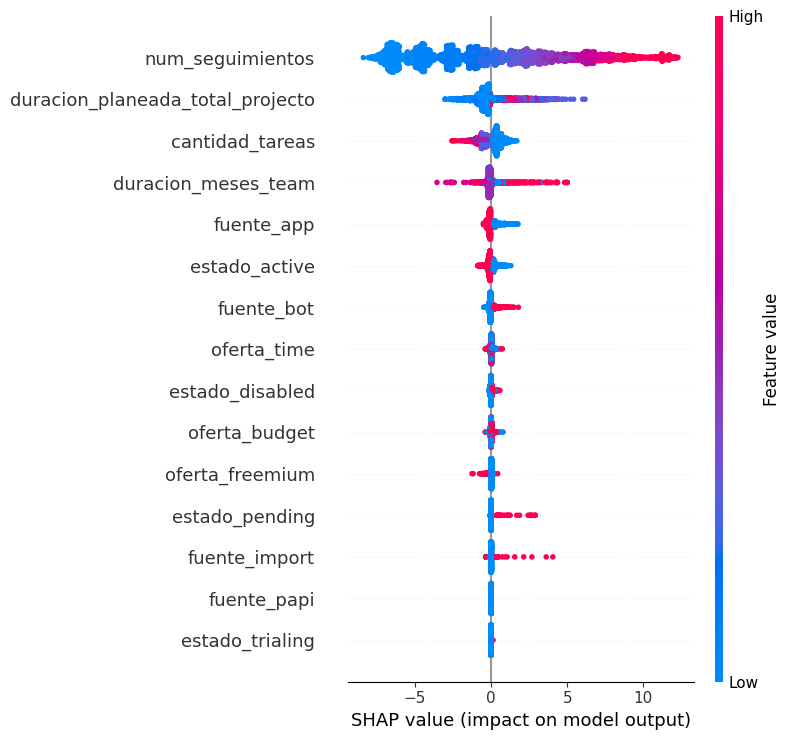

In [27]:
explainer = shap.TreeExplainer(best_rf)
shap_values = explainer.shap_values(X_test_final)
shap.summary_plot(shap_values, X_test_final)

Los resultados del análisis SHAP muestran que las variables con mayor influencia en la predicción de las horas reales del proyecto son el número de seguimientos, la duración planeada total y la cantidad de tareas.
El número de seguimientos muestra un impacto claramente positivo: a mayor seguimiento, mayores son las horas reales estimadas. Esto indica que proyectos con más revisiones, controles o ajustes suelen ser más complejos y requieren mayor esfuerzo.
La duración planeada total también presenta una relación directa: cuando aumenta la duración estimada en la planificación, aumentan proporcionalmente las horas reales, reflejando que la planificación ya captura parte de la complejidad del proyecto.
Por su parte, la cantidad de tareas muestra una relación inversa: menos tareas se asocian con más horas reales, lo que sugiere proyectos con pocas actividades pero de alta complejidad o larga duración, como infraestructura o modelado.
En conjunto, estos patrones evidencian que el modelo identifica correctamente cómo la intensidad del seguimiento, la planificación inicial y la estructura de tareas influyen en la duración real de los proyectos.

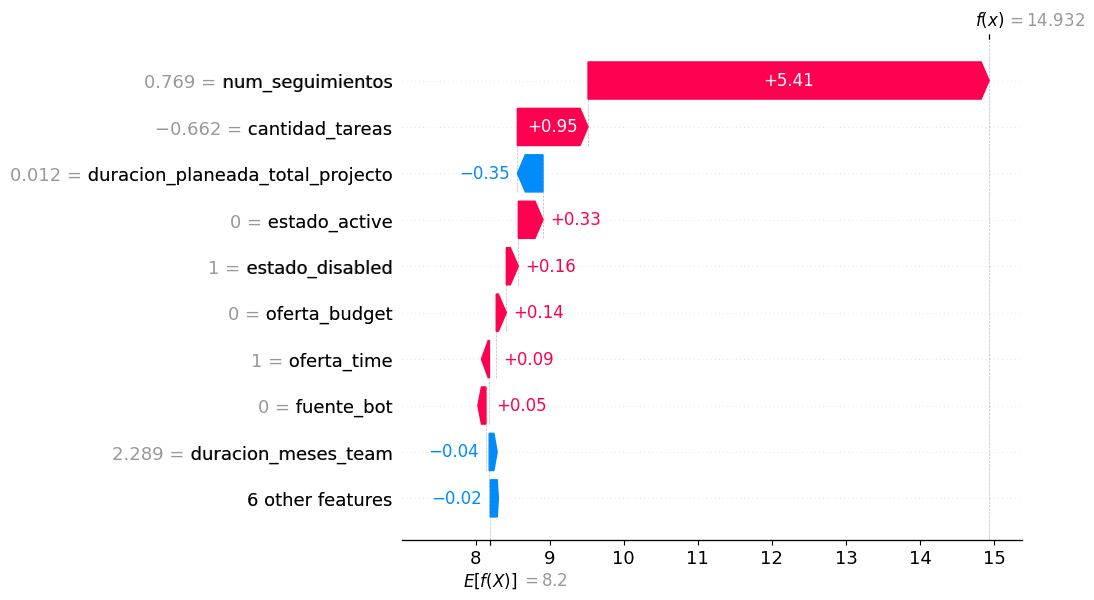

In [26]:
# Crear el explainer
explainer = shap.TreeExplainer(best_rf)
shap_values = explainer(X_test_final)
import matplotlib.ticker as ticker
# generar shap values normales

# escalar SHAP

shap_values_scaled = shap.Explanation(
    values = shap_values.values.copy(),
    base_values = shap_values.base_values.copy(),
    data = shap_values.data.copy(),
    feature_names = shap_values.feature_names
)
# graficar un caso
i = 0
shap.plots.waterfall(shap_values_scaled[i])

La predicción base del modelo es de 8.2 horas, pero para este caso aumenta a ≈15 horas debido principalmente a tres variables: num_seguimientos, cantidad_tareas y los estados administrativos del proyecto.

- num_seguimientos es el factor más determinante, agregando +5.47 horas. Esto indica que los proyectos con más seguimiento tienden a ser más complejos, requieren más revisiones y por tanto consumen más horas reales.
- cantidad_tareas también incrementa la duración (+0.96 h), reflejando proyectos con pocas tareas pero de alta complejidad (por ejemplo, despliegues técnicos o modelado).
Diversos estados del proyecto (estado_active, estado_disabled, modalidades de oferta) suman horas adicionales, mostrando que este caso tiene una carga administrativa mayor.
- Por otro lado, variables como duracion_planeada_total_proyecto y duracion_meses_team tienen un efecto negativo leve, reduciendo la duración. Esto suele asociarse a proyectos mejor planificados o con equipos más maduros, lo que ayuda a contener tiempos. En conjunto, el modelo interpreta este proyecto como uno complejo y demandante, lo que justifica que la predicción final casi duplique el tiempo promedio.

- Despliegue modelo

In [ ]:
# ============================================================
# Persistencia de componentes del modelo para despliegue
# ============================================================
# Este bloque guarda en disco todos los artefactos necesarios
# para reproducir las predicciones del modelo en producción.
# Se almacenan por separado el modelo entrenado, los
# transformadores utilizados durante el preprocesamiento y la
# lista final de columnas empleadas, garantizando que cualquier
# sistema externo (API, aplicación web o script de inferencia)
# pueda reconstruir el pipeline completo de transformación.

import joblib
joblib.dump(best_rf, 'model/rf.joblib')

# Guardar el codificador OHE
joblib.dump(ohe, 'model/one_hot_encoder.joblib')

# Guardar el escalador StandardScaler
joblib.dump(scaler, 'model/standard_scaler.joblib')

# Guardar la lista final de nombres de columnas
final_columns = X_train_final.columns.tolist()
joblib.dump(final_columns, 'model/final_columns.joblib')

['model/final_columns.joblib']